# Initial density profile: current vs. Nabarro-Herring vs. Densific

In `source/initialise_model.f90 :: Init_Density_Prof`, the layer-by-layer density increment is:

```fortran
part1 = (rhoi - rho) * exp((-Ec + Eg) / (R * T))
drho  = 0.07 * dzmax * rho * g * part1    ! stage 1 (rho <= 550)
drho  = 0.03 * dzmax * rho * g * part1    ! stage 2 (rho > 550)
```

In `source/firn_physics.f90 :: Densific` (the time-loop), the Nabarro-Herring form uses **acav** as the loading term and an accumulation-dependent MO fit as a pre-factor:

```fortran
MO_low  = 0.7522 - 0.0178*log(acav)
MO_high = 5.7819 * (acav**(-0.4187)) + 0.0527
corr    = 0.07 * MO_low                              ! or 0.03 * MO_high
part1   = exp(-Ec/(R*T(ind_z)) + Eg/(R*T(1)))
Krate   = corr * acav * g * part1
dRho    = (dt/spy) * Krate * (rhoi - Rho)
```

This notebook compares three formulations applied as initial profiles (replacing `dt/spy` with `dzmax`):

| Mode | Loading proxy | Pre-factor |
|------|--------------|------------|
| **`current`** | `rho · dzmax` | 0.07 / 0.03 |
| **`bave`** | `acav · dzmax` | 0.07 / 0.03 |
| **`densific`** | `acav · dzmax` | `0.07·MO_low` / `0.03·MO_high` |

`acav` is in **mm w.e. yr⁻¹** throughout. Constants from `model_settings.f90`; `dzmax = 0.15 m` (FGRN055 default).


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [9]:
# Physical constants (from model_settings.f90 :: Define_Constants)
rhoi = 917.0       # ice density [kg m-3]
R    = 8.3145      # gas constant [J mol-1 K-1]
Ec   = 60000.0     # activation energy for creep [J mol-1]
Eg   = 42400.0     # activation energy for grain growth [J mol-1]
g    = 9.81        # gravitational acceleration [m s-2]
Tmelt = 273.15     # melting point [K]

# Model resolution (from model_settings_FGRN055_*.txt)
dzmax = 0.15       # layer thickness [m]
n_layers = 1000    # max layers to integrate (= 150 m column)

# Fausto et al. (2018) surface density for Greenland/FGRN055
def rho0_fausto(tsav):
    return 362.1 + 2.78 * (tsav - Tmelt)

In [ ]:
def init_density_profile(tsav, acav, mode="current", rho0=None):
    """
    Python translation of Init_Density_Prof, extended with Nabarro-Herring modes.

    Parameters
    ----------
    tsav : float  Mean annual surface temperature [K]
    acav : float  Mean annual accumulation [mm w.e. yr-1]
    mode : str
        'current'  — 0.07/0.03 * dzmax * rho * g * part1
                     (as coded in Init_Density_Prof)
        'bave'     — 0.07/0.03 * dzmax * acav * g * part1
                     (Nabarro-Herring: acav as loading proxy, no MO correction)
        'densific' — 0.07*MO_low / 0.03*MO_high * dzmax * acav * g * part1
                     (mirrors Densific in firn_physics.f90)
    rho0 : float or None  Surface density [kg m-3]; defaults to Fausto et al. 2018

    Note: Init_Density_Prof uses a uniform tsav for part1 throughout the column.
    Densific uses T(ind_z) per layer and T(1) for the Eg term; here both use tsav
    to stay comparable with the init context.
    """
    if rho0 is None:
        rho0 = rho0_fausto(tsav)

    rho_col = np.zeros(n_layers)
    depth   = np.zeros(n_layers)
    rho_col[0] = rho0
    depth[0]   = dzmax / 2.0

    base_exp = np.exp((-Ec / (R * tsav)) + (Eg / (R * tsav)))

    if mode == "densific":
        c1 = 0.07 * MO_low(acav)
        c2 = 0.03 * MO_high(acav)

    for i in range(1, n_layers):
        rho_prev = rho_col[i - 1]
        part1    = (rhoi - rho_prev) * base_exp

        if rho_prev <= 550.0:
            if   mode == "current":   drho = 0.07 * dzmax * rho_prev * g * part1
            elif mode == "bave":      drho = 0.07 * dzmax     * g * part1
            elif mode == "densific":  drho = c1   * dzmax * acav     * g * part1
            else: raise ValueError(f"Unknown mode: {mode}")
        else:
            if   mode == "current":   drho = 0.03 * dzmax * rho_prev * g * part1
            elif mode == "bave":      drho = 0.03 * dzmax * 1/np.sqrt(acav*1000./917.)     * g * part1
            elif mode == "densific":  drho = c2   * dzmax * acav     * g * part1
            else: raise ValueError(f"Unknown mode: {mode}")

        rho_col[i] = min(rho_prev + drho, rhoi)
        depth[i]   = depth[i - 1] + dzmax

    return depth, rho_col


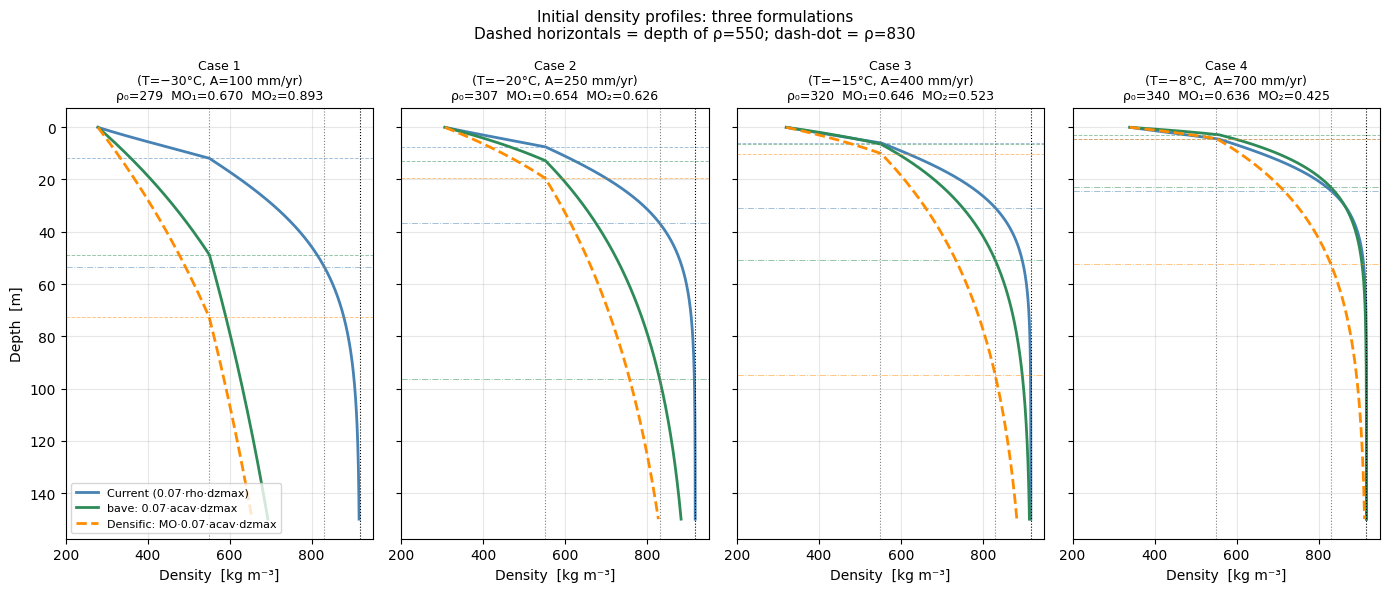

In [18]:
cases = [
    {"label": "Case 1\n(T=−30°C, A=100 mm/yr)",    "tsav": 243.15, "acav": 100},
    {"label": "Case 2\n(T=−20°C, A=250 mm/yr)", "tsav": 253.15, "acav": 250},
    {"label": "Case 3\n(T=−15°C, A=400 mm/yr)",   "tsav": 258.15, "acav": 400},
    {"label": "Case 4\n(T=−8°C,  A=700 mm/yr)", "tsav": 265.15, "acav": 700},
]

variants = [
    ("current",  "steelblue",  "-",  "Current (0.07·rho·dzmax)"),
    ("bave",     "seagreen",   "-",  "bave: 0.07·acav·dzmax"),
    ("densific", "darkorange", "--", "Densific: MO·0.07·acav·dzmax"),
]

fig, axes = plt.subplots(1, len(cases), figsize=(14, 6), sharey=True)

for ax, case in zip(axes, cases):
    tsav = case["tsav"]; acav = case["acav"]

    for mode, color, ls, label in variants:
        depth, rho = init_density_profile(tsav, acav, mode=mode)
        ax.plot(rho, depth, lw=2.0, color=color, ls=ls, label=label)

        for target, lsa in [(550, "--"), (830, "-.")]:
            idx = np.searchsorted(rho, target)
            if idx < len(depth):
                ax.axhline(depth[idx], color=color, lw=0.7, ls=lsa, alpha=0.5)

    ax.axvline(550,  color="grey", lw=0.8, ls=":")
    ax.axvline(830,  color="grey", lw=0.8, ls=":")
    ax.axvline(rhoi, color="k",    lw=0.8, ls=":")

    rho0 = rho0_fausto(tsav)
    ax.set_title(case["label"] + f"\nρ₀={rho0:.0f}  MO₁={MO_low(acav):.3f}  MO₂={MO_high(acav):.3f}", fontsize=9)
    ax.set_xlabel("Density  [kg m⁻³]")
    ax.set_xlim(200, 950); ax.grid(True, alpha=0.3)
    if ax == axes[0]:
        ax.set_ylabel("Depth  [m]")
        ax.legend(fontsize=8, loc="lower left")
        
ax.invert_yaxis()

fig.suptitle(
    "Initial density profiles: three formulations\n"
    "Dashed horizontals = depth of ρ=550; dash-dot = ρ=830",
    fontsize=11
)
plt.tight_layout()
plt.show()


In [ ]:
def depth_at(rho_arr, depth_arr, target):
    idx = np.searchsorted(rho_arr, target)
    return f"{depth_arr[idx]:.1f} m" if idx < len(depth_arr) else ">150 m"

modes = ("current", "bave", "densific")
w = 8
header = f"{'Case':<38} {'ρ₀':>5}  " + "".join(
    f"{'d550':>{w}} {'d830':>{w}} {'dice':>{w}}   " for _ in modes
)
subhdr = f"{'':38} {'':5}  " + "".join(
    f"{m:>{w}} {m:>{w}} {m:>{w}}   " for m in modes
)
print(header); print(subhdr); print("-" * 120)

for case in cases:
    tsav = case["tsav"]; acav = case["acav"]
    profiles = {m: init_density_profile(tsav, acav, mode=m) for m in modes}
    rho0  = rho0_fausto(tsav)
    label = case['label'].replace('\n', ' ')
    row = f"{label:<38} {rho0:>5.0f}  "
    for m in modes:
        d, r = profiles[m]
        row += f"{depth_at(r,d,550):>{w}} {depth_at(r,d,830):>{w}} {depth_at(r,d,rhoi-0.5):>{w}}   "
    print(row)


In [ ]:
acav_vals  = np.arange(50, 1500, 25)
tsav_fixed = 258.15  # -15°C

colors = {"current": "steelblue", "bave": "seagreen", "densific": "darkorange"}
labels = {
    "current":  "Current (0.07·rho·dzmax)",
    "bave":     "bave: 0.07·acav·dzmax",
    "densific": "Densific: MO·0.07·acav·dzmax",
}
lss = {"current": "-", "bave": "-", "densific": "--"}

# ── Single panel: z830 vs acav at fixed T ───────────────────────────────────
results = {m: [] for m in colors}
for ac in acav_vals:
    for mode in results:
        depth, rho = init_density_profile(tsav_fixed, ac, mode=mode)
        idx = np.searchsorted(rho, 830.0)
        results[mode].append(depth[idx] if idx < n_layers else np.nan)

fig, ax = plt.subplots(figsize=(7, 4))
for mode, vals in results.items():
    ax.plot(acav_vals, vals, lw=2, color=colors[mode], ls=lss[mode], label=labels[mode])
ax.set_xlabel("acav  [mm w.e. yr⁻¹]")
ax.set_ylabel("Depth of ρ = 830 kg m⁻³  [m]")
ax.set_title(f"Initial z₈₃₀ depth vs. acav  (T = {tsav_fixed - 273.15:.0f}°C)")
ax.invert_yaxis(); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── Three-panel: z830 vs acav across temperatures ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, tsav in zip(axes, [243.15, 253.15, 263.15]):
    for mode in colors:
        d_list = []
        for ac in acav_vals:
            depth, rho = init_density_profile(tsav, ac, mode=mode)
            idx = np.searchsorted(rho, 830.0)
            d_list.append(depth[idx] if idx < n_layers else np.nan)
        ax.plot(acav_vals, d_list, lw=2, color=colors[mode], ls=lss[mode], label=labels[mode])
    ax.set_xlabel("acav  [mm w.e. yr⁻¹]")
    ax.set_title(f"T = {tsav - 273.15:.0f}°C")
    ax.invert_yaxis(); ax.grid(True, alpha=0.3)
    if ax == axes[0]:
        ax.set_ylabel("Depth of ρ = 830 kg m⁻³  [m]")
        ax.legend(fontsize=8)

fig.suptitle("z₈₃₀ depth vs. acav — three init formulations", fontsize=11)
plt.tight_layout(); plt.show()
